# 1.5. UMAP — pełny algorytm matematycznie, krok po kroku

Materiał jest inspirowany stylem dydaktycznym StatQuest, ale rysunki i obliczenia są przygotowane od zera.

Ten notebook kontynuuje przykład z punktami $A,B,C,D,E,F$ i pokazuje pełną ścieżkę UMAP:

$$
\text{odległości}
\rightarrow
kNN
\rightarrow
\rho_i,\sigma_i
\rightarrow
\text{kierunkowe similarity}
\rightarrow
\text{fuzzy union}
\rightarrow
P
\rightarrow
\text{inicjalizacja niskowymiarowa}
\rightarrow
Q
\rightarrow
\text{optymalizacja}.
$$


## W tym notebooku użyjemy

✓ Macierzy odległości D

✓ Grafu kNN

✓ Ważonej macierzy sąsiedztwa A

## Obiekty matematyczne

Wejście:

✓ Punkty danych X

Budujemy:

✓ Macierz odległości D
✓ Graf kNN
✓ Ważoną macierz sąsiedztwa A

Wynik:

✓ Nowe współrzędne 2D

## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)

labels = list("ABCDEF")
colors = {
    "A": "tab:blue", "B": "tab:red", "C": "tab:pink",
    "D": "gold", "E": "khaki", "F": "lemonchiffon"
}

# Ręcznie ustawiona macierz odległości inspirowana przykładem A,B,C oraz osobną grupą D,E,F.
# Ważne: A,B,C są jedną lokalną grupą, D,E,F drugą lokalną grupą.
D = np.array([
    [0.0, 0.5, 2.4, 10.0,  9.5,  9.8],
    [0.5, 0.0, 2.0,  9.8,  9.0,  9.2],
    [2.4, 2.0, 0.0,  8.0,  8.2,  8.0],
    [10.0,9.8, 8.0,  0.0,  0.5,  0.3],
    [9.5, 9.0, 8.2,  0.5,  0.0,  0.4],
    [9.8, 9.2, 8.0,  0.3,  0.4,  0.0],
])

coords = {
    "A": (0.0, 1.3),
    "B": (0.0, 0.8),
    "C": (2.2, 0.25),
    "D": (7.2, 0.85),
    "E": (7.8, 0.85),
    "F": (7.5, 0.45),
}
X_plot = np.array([coords[l] for l in labels])

def df_matrix(M, fmt=True):
    df = pd.DataFrame(M, index=labels, columns=labels)
    return df.round(3) if fmt else df

def plot_points(ax=None, title="Punkty wejściowe", annotate_distances=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3.6))
    for i, lab in enumerate(labels):
        ax.scatter(X_plot[i,0], X_plot[i,1], s=260, color=colors[lab], edgecolor='black', zorder=3)
        ax.text(X_plot[i,0], X_plot[i,1]+0.18, lab, ha='center', va='bottom', fontsize=14, fontweight='bold')
    if annotate_distances:
        pairs = [("A","B",0.5),("B","C",2.0),("A","C",2.4),("D","E",0.5),("D","F",0.3),("E","F",0.4)]
        for a,b,val in pairs:
            ia, ib = labels.index(a), labels.index(b)
            xa, ya = X_plot[ia]
            xb, yb = X_plot[ib]
            ax.plot([xa,xb],[ya,yb], color='0.75', linestyle='--', zorder=1)
            ax.text((xa+xb)/2, (ya+yb)/2+0.08, f"{val}", ha='center', fontsize=10, color='0.35')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-0.8, 8.6)
    ax.set_ylim(-0.2, 1.8)
    ax.axis('off')
    return ax

def plot_heatmap(M, title, ax=None, vmin=0, vmax=1, cmap='Reds', annotate=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(title)
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i,j]
                txt = "" if np.isnan(val) else f"{val:.2f}"
                ax.text(j, i, txt, ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

def directed_knn_indices(D, n_neighbors=2):
    neigh = []
    for i in range(D.shape[0]):
        order = np.argsort(D[i])
        order = [j for j in order if j != i]
        neigh.append(order[:n_neighbors])
    return neigh

def solve_sigma_for_two_neighbors(distances, target=np.log2(3)):
    # Zakładamy local_connectivity=1: najbliższy sąsiad po przesunięciu rho ma wagę 1.
    # Dla drugiego sąsiada dobieramy sigma tak, aby 1 + exp(-(d2-rho)/sigma) = target.
    rho = min(distances)
    other = max(distances)
    desired_other = target - 1.0
    if other == rho:
        return 1.0, rho
    sigma = (other - rho) / (-np.log(desired_other))
    return sigma, rho

def umap_directed_scores(D, n_neighbors=2, target=np.log2(3)):
    n = D.shape[0]
    neigh = directed_knn_indices(D, n_neighbors=n_neighbors)
    Pdir = np.zeros((n,n))
    sigmas = np.zeros(n)
    rhos = np.zeros(n)
    for i in range(n):
        distances = [D[i,j] for j in neigh[i]]
        sigma, rho = solve_sigma_for_two_neighbors(distances, target=target)
        sigmas[i] = sigma
        rhos[i] = rho
        for j in neigh[i]:
            Pdir[i,j] = np.exp(-max(0.0, D[i,j]-rho)/sigma)
    return Pdir, np.array(sigmas), np.array(rhos), neigh

def fuzzy_union(Pdir):
    return Pdir + Pdir.T - Pdir * Pdir.T

def low_dim_q_umap(y, a=1.577, b=0.8951):
    y = np.asarray(y).reshape(-1, 1)
    dist = np.abs(y - y.T)
    Q = 1.0 / (1.0 + a * (dist ** (2*b)))
    np.fill_diagonal(Q, 1.0)
    return Q

def cross_entropy_binary(P, Q, eps=1e-7):
    mask = ~np.eye(P.shape[0], dtype=bool)
    Pm = P[mask]
    Qm = np.clip(Q[mask], eps, 1-eps)
    return -np.sum(Pm*np.log(Qm) + (1-Pm)*np.log(1-Qm)) / 2


## 1. Dane i odległości

UMAP nie zaczyna od rysunku 2D. Zaczyna od danych i odległości.

W notebooku używamy ręcznie ustawionej macierzy odległości, żeby łatwo śledzić obliczenia.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.8))
plot_points(ax, title="Dane wejściowe: dwie lokalne grupy")
plt.show()

display(df_matrix(D))


## 2. Krok UMAP 1: graf k najbliższych sąsiadów

UMAP nie używa wszystkich par punktów jednakowo.

Najpierw dla każdego punktu wybiera lokalne sąsiedztwo:

$$
kNN(i)=\{\text{k najbliższych punktów do } i\}.
$$

W naszym małym przykładzie bierzemy dwóch najbliższych sąsiadów dla każdego punktu.


In [ ]:
neigh = directed_knn_indices(D, n_neighbors=2)
rows = []
for i, ns in enumerate(neigh):
    rows.append({"punkt": labels[i], "sąsiad 1": labels[ns[0]], "d1": D[i,ns[0]], "sąsiad 2": labels[ns[1]], "d2": D[i,ns[1]]})
display(pd.DataFrame(rows))

A_knn = np.zeros_like(D)
for i, ns in enumerate(neigh):
    for j in ns:
        A_knn[i,j] = 1
fig, ax = plt.subplots(figsize=(5.2,4.2))
plot_heatmap(A_knn, "Kierunkowy graf kNN", ax=ax, cmap='Greys')
plt.show()


## 3. Krok UMAP 2: lokalne parametry $\rho_i$ i $\sigma_i$

Dla każdego punktu UMAP liczy:

$$
\rho_i = \min_{j\in kNN(i)} d(x_i,x_j).
$$

Potem dobiera $\sigma_i$ tak, aby lokalna suma wag miała zadany poziom:

$$
\sum_{j\in kNN(i)} \exp\left(-\frac{\max(0,d(x_i,x_j)-\rho_i)}{\sigma_i}\right)
\approx \log_2(k_{\text{eff}}).
$$

W tym mini-przykładzie używamy celu:

$$
\log_2(3)\approx 1.585,
$$

bo chcemy odtworzyć ręczne wartości typu $\sigma_A\approx 3.5$ i $\sigma_B\approx 2.8$.


In [ ]:
Pdir, sigmas, rhos, neigh = umap_directed_scores(D, n_neighbors=2, target=np.log2(3))
params = pd.DataFrame({"punkt": labels, "rho_i": rhos, "sigma_i": sigmas, "suma wag": Pdir.sum(axis=1)})
display(params.round(4))


## 4. Krok UMAP 3: kierunkowe similarity scores

Dla sąsiada $j\in kNN(i)$:

$$
 p(j\mid i)=
 \exp\left(-\frac{\max(0,d(x_i,x_j)-\rho_i)}{\sigma_i}\right).
$$

Dla punktów spoza kNN:

$$
 p(j\mid i)=0.
$$

To jest bardzo ważne: macierz UMAP jest **rzadka**. Punkty $D,E,F$ nie są sąsiadami $A$, więc w wierszu $A$ mają score $0$.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
plot_heatmap(Pdir, "Kierunkowe p(j|i)", ax=axes[0], cmap='Reds')
plot_points(axes[1], title="Lokalne grafy w dwóch grupach", annotate_distances=False)
for i, ns in enumerate(neigh):
    xi, yi = X_plot[i]
    for j in ns:
        xj, yj = X_plot[j]
        axes[1].annotate("", xy=(xj,yj), xytext=(xi,yi), arrowprops=dict(arrowstyle="->", lw=1.8, alpha=0.65))
plt.tight_layout()
plt.show()

display(df_matrix(Pdir))


## 5. Krok UMAP 4: fuzzy union, czyli graf symetryczny $P$

Po kroku kierunkowym mamy dwie możliwe wagi między $i$ i $j$:

$$
 p(j\mid i),\qquad p(i\mid j).
$$

UMAP łączy je przez fuzzy union:

$$
 P_{ij}=p(j\mid i)+p(i\mid j)-p(j\mid i)p(i\mid j).
$$

Przykłady:

$$
0.6+1.0-0.6\cdot 1.0=1.0,
$$

$$
0.6+0.6-0.6\cdot 0.6=0.84.
$$

Po tym kroku dostajemy docelowy graf wysokowymiarowy $P$.


In [ ]:
P = fuzzy_union(Pdir)
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
plot_heatmap(Pdir, "Kierunkowe p(j|i)", ax=axes[0], cmap='Reds')
plot_heatmap(P, "Docelowy fuzzy graf P", ax=axes[1], cmap='Reds')
plt.tight_layout()
plt.show()

display(df_matrix(P))


## 6. Krok UMAP 5: inicjalizacja niskowymiarowa

W praktycznym UMAP często używa się inicjalizacji spektralnej, czyli startowego ustawienia punktów wyliczonego z grafu.

Intuicja:

> Jeśli graf mówi, że $A,B,C$ są mocno połączone, a $D,E,F$ są mocno połączone osobno, to startowa mapa powinna już częściowo widzieć te dwie grupy.

Poniżej liczymy prostą 1D inicjalizację spektralną z Laplasjanu grafu:

$$
L = \operatorname{diag}(P\mathbf{1}) - P.
$$

Bierzemy jeden z najmniejszych nietrywialnych wektorów własnych jako współrzędną 1D.


In [ ]:
# Uproszczona inicjalizacja spektralna 1D.
W = P.copy()
np.fill_diagonal(W, 0)
deg = W.sum(axis=1)
L = np.diag(deg) - W
vals, vecs = np.linalg.eigh(L)
# Wybieramy drugi/trzeci nietrywialny wektor; przy rozłącznych komponentach jest kilka zerowych.
# Dla stabilności bierzemy ostatni z małych wektorów, który rozdziela komponenty, albo losowy start jeśli degeneracja.
y_spectral = vecs[:, 1]
y_spectral = (y_spectral - y_spectral.mean()) / (y_spectral.std() + 1e-9)

fig, ax = plt.subplots(figsize=(8,2.2))
for i, lab in enumerate(labels):
    ax.scatter(y_spectral[i], 0, s=240, color=colors[lab], edgecolor='black', zorder=3)
    ax.text(y_spectral[i], 0.13, lab, ha='center', fontsize=13, fontweight='bold')
ax.axhline(0, color='0.75')
ax.set_yticks([])
ax.set_title("Przykładowa inicjalizacja 1D z grafu")
plt.show()

display(pd.DataFrame({"punkt": labels, "y_init": y_spectral}).round(3))


## 7. Krok UMAP 6: niskowymiarowe similarity scores $Q$

Po ustawieniu punktów w niskim wymiarze UMAP liczy aktualne podobieństwa:

$$
 Q_{ij}=\frac{1}{1+a\lVert y_i-y_j\rVert^{2b}}.
$$

Dla domyślnych parametrów `min_dist=0.1`, `spread=1.0` często pojawiają się wartości przybliżone:

$$
 a\approx 1.577,\qquad b\approx 0.8951.
$$

Jeśli ustawimy:

$$
 a=1,\qquad b=1,
$$

to dostajemy kształt używany w niskowymiarowej części t-SNE:

$$
 Q_{ij}=\frac{1}{1+\lVert y_i-y_j\rVert^2}.
$$

Różnica: t-SNE potem normalizuje te wartości globalnie do prawdopodobieństw, a UMAP traktuje $Q_{ij}$ jako fuzzy membership w przedziale $[0,1]$.


In [ ]:
# Porównanie krzywych low-dimensional similarity
x = np.linspace(0, 5, 300)
a_default, b_default = 1.577, 0.8951
q_umap = 1/(1 + a_default * x**(2*b_default))
q_tsne_shape = 1/(1 + x**2)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, q_umap, label="UMAP: a=1.577, b=0.8951")
ax.plot(x, q_tsne_shape, label="t-SNE shape: a=1, b=1", linestyle='--')
ax.set_xlabel("odległość w niskim wymiarze")
ax.set_ylabel("low-dimensional similarity")
ax.set_title("Kształt funkcji Q(d)")
ax.legend()
plt.show()

Q_init = low_dim_q_umap(y_spectral, a=a_default, b=b_default)
fig, ax = plt.subplots(figsize=(5.2,4.2))
plot_heatmap(Q_init, "Q z inicjalizacji 1D", ax=ax, cmap='Reds')
plt.show()


## 8. Krok UMAP 7: dopasowanie $Q$ do $P$

Mamy dwa grafy:

- $P_{ij}$ — podobieństwa z oryginalnej przestrzeni,
- $Q_{ij}$ — podobieństwa z niskowymiarowej mapy.

UMAP przesuwa punkty tak, aby $Q$ było podobne do $P$.

Uproszczona postać funkcji kosztu to binarna cross-entropy:

$$
\mathcal{L}(P,Q)=
-\sum_{i<j}\left[
P_{ij}\log Q_{ij}
+(1-P_{ij})\log(1-Q_{ij})
\right].
$$

Intuicyjnie:

- jeśli $P_{ij}$ jest duże, punkty powinny się przyciągać,
- jeśli $P_{ij}$ jest małe, punkty powinny się odpychać.

W prawdziwym `umap-learn` optymalizacja jest robiona wydajniej, z próbkowaniem negatywnym. Tutaj robimy małą edukacyjną wersję na sześciu punktach.


In [ ]:
def umap_loss_for_y(y, P, a=1.577, b=0.8951):
    Q = low_dim_q_umap(y, a=a, b=b)
    return cross_entropy_binary(P, Q)

def numeric_grad(f, y, eps=1e-5):
    g = np.zeros_like(y)
    for i in range(len(y)):
        yp = y.copy(); ym = y.copy()
        yp[i] += eps; ym[i] -= eps
        g[i] = (f(yp) - f(ym)) / (2*eps)
    return g

def optimize_y(y0, P, steps=160, lr=0.04, a=1.577, b=0.8951):
    y = y0.astype(float).copy()
    hist = []
    for t in range(steps+1):
        loss = umap_loss_for_y(y, P, a=a, b=b)
        hist.append((t, y.copy(), loss, low_dim_q_umap(y, a=a, b=b)))
        g = numeric_grad(lambda z: umap_loss_for_y(z, P, a=a, b=b), y)
        y -= lr*g
        y -= y.mean()
        # stabilizacja skali, żeby punkty nie uciekły zbyt daleko w dydaktycznym przykładzie
        y = np.clip(y, -6, 6)
    return hist

# Celowo używamy nieidealnego startu, aby było widać poprawę macierzy Q.
y0 = np.array([3.8, 1.6, 5.0, -2.2, 0.2, 0.6])
hist = optimize_y(y0, P, steps=120, lr=0.025)

for idx in [0, 20, 60, 120]:
    t, y, loss, Q = hist[idx]
    print(f"iteracja={t:3d}, loss={loss:.4f}, y={np.round(y,2)}")


In [ ]:
# Porównanie początku i końca
for idx, name in [(0, "start"), (-1, "koniec")]:
    t, y, loss, Q = hist[idx]
    fig, axes = plt.subplots(1, 3, figsize=(14,3.8))
    plot_heatmap(P, "Docelowy P", ax=axes[0], cmap='Reds')
    plot_heatmap(Q, f"Aktualny Q: {name}\nloss={loss:.2f}", ax=axes[1], cmap='Reds')
    plot_heatmap(np.abs(P-Q), f"Błąd |P-Q|: {name}", ax=axes[2], cmap='Blues')
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(8,2.2))
    for i, lab in enumerate(labels):
        ax.scatter(y[i], 0, s=240, color=colors[lab], edgecolor='black', zorder=3)
        ax.text(y[i], 0.13, lab, ha='center', fontsize=13, fontweight='bold')
    ax.axhline(0, color='0.75')
    ax.set_yticks([])
    ax.set_title(f"Punkty 1D — {name}, iteracja {t}")
    plt.show()


## 9. Cały algorytm UMAP w jednej liście

1. Policz odległości między punktami.
2. Dla każdego punktu znajdź $k$ najbliższych sąsiadów.
3. Dla każdego punktu policz lokalne $\rho_i$ i $\sigma_i$.
4. Zamień odległości na kierunkowe similarity scores:

$$
 p(j\mid i)=\exp\left(-\frac{\max(0,d(x_i,x_j)-\rho_i)}{\sigma_i}\right).
$$

5. Zrób symetryczny fuzzy graf:

$$
P_{ij}=p(j\mid i)+p(i\mid j)-p(j\mid i)p(i\mid j).
$$

6. Zainicjalizuj punkty w niskim wymiarze.
7. Policz niskowymiarowe similarity:

$$
 Q_{ij}=\frac{1}{1+a\lVert y_i-y_j\rVert^{2b}}.
$$

8. Przesuwaj punkty tak, aby $Q$ było podobne do $P$.
9. Wynik końcowy to mapa, która zachowuje lokalny fuzzy graf sąsiedztw.

Najważniejsza intuicja:

> UMAP nie próbuje zachować wszystkich odległości. UMAP próbuje zachować lokalną strukturę grafu sąsiedztw.


# KL divergence i cross-entropy

## KL divergence i cross-entropy

Mamy dwa rozkłady:

- $P$ — rozkład docelowy / prawdziwy,
- $Q$ — rozkład modelu.

Cross-entropy:

$$
H(P,Q) = -\sum_i P_i \log Q_i
$$

KL divergence:

$$
KL(P||Q)=\sum_i P_i \log\frac{P_i}{Q_i}
$$

Związek:

$$
H(P,Q)=H(P)+KL(P||Q)
$$

gdzie:

$$
H(P)=-\sum_i P_i\log P_i
$$

Jeśli $P$ jest stałe, to minimalizowanie cross-entropy względem $Q$ jest równoważne minimalizowaniu $KL(P||Q)$.

Różnica intuicyjna:

- cross-entropy mierzy całkowity koszt kodowania,
- KL divergence mierzy dodatkowy koszt wynikający z niedopasowania modelu.

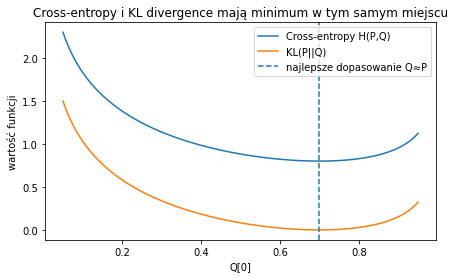

In [1]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12

P = np.array([0.7, 0.2, 0.1])
q1_values = np.linspace(0.05, 0.95, 300)

cross_entropies = []
kl_values = []

for q1 in q1_values:
    rest = 1 - q1
    Q = np.array([q1, rest * 0.7, rest * 0.3])
    Q = np.clip(Q, eps, 1)

    H_P = -np.sum(P * np.log(P + eps))
    H_PQ = -np.sum(P * np.log(Q + eps))
    KL = np.sum(P * np.log((P + eps) / (Q + eps)))

    cross_entropies.append(H_PQ)
    kl_values.append(KL)

plt.figure(figsize=(7, 4))
plt.plot(q1_values, cross_entropies, label="Cross-entropy H(P,Q)")
plt.plot(q1_values, kl_values, label="KL(P||Q)")
plt.axvline(P[0], linestyle="--", label="najlepsze dopasowanie Q≈P")
plt.xlabel("Q[0]")
plt.ylabel("wartość funkcji")
plt.title("Cross-entropy i KL divergence mają minimum w tym samym miejscu")
plt.legend()
plt.show()

# Cross-entropy vs KL divergence — intuicja praktyczna

Porównujemy dwa rozkłady prawdopodobieństwa:

- $P$ — rozkład docelowy, prawdziwy albo referencyjny,
- $Q$ — rozkład modelu, predykcji albo przybliżenia.

Cross-entropy definiujemy jako:

$$
H(P,Q) = - \sum_i P_i \log Q_i
$$

KL divergence definiujemy jako:

$$
KL(P||Q) = \sum_i P_i \log \frac{P_i}{Q_i}
$$

Entropia samego rozkładu $P$ to:

$$
H(P) = - \sum_i P_i \log P_i
$$

Między cross-entropy i KL divergence zachodzi zależność:

$$
H(P,Q) = H(P) + KL(P||Q)
$$

Czyli:

> Cross-entropy to naturalna trudność danych plus kara za niedopasowanie modelu.

Inaczej:

- $H(P)$ mówi, jak niepewny jest sam rozkład docelowy.
- $KL(P||Q)$ mówi, ile tracimy przez to, że używamy $Q$ zamiast $P$.
- $H(P,Q)$ mówi, jaki jest całkowity koszt używania $Q$ do opisu danych pochodzących z $P$.

Ważna uwaga: KL divergence nie jest klasyczną metryką odległości, bo zwykle:

$$
KL(P||Q) \neq KL(Q||P)
$$

Czyli kierunek porównania ma znaczenie.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

EPS = 1e-12

def normalize(x):
    """
    Normalizuje wektor tak, aby suma elementów wynosiła 1.
    Dzięki temu możemy traktować go jako rozkład prawdopodobieństwa.
    """
    x = np.asarray(x, dtype=float)
    return x / x.sum()

def entropy(P):
    """
    Entropia rozkładu P.

    Mierzy naturalną niepewność samego rozkładu P.
    """
    P = normalize(P)
    return -np.sum(P * np.log(P + EPS))

def cross_entropy(P, Q):
    """
    Cross-entropy H(P, Q).

    Mierzy koszt używania rozkładu Q,
    gdy prawdziwy rozkład to P.
    """
    P = normalize(P)
    Q = normalize(Q)
    return -np.sum(P * np.log(Q + EPS))

def kl_divergence(P, Q):
    """
    KL divergence KL(P || Q).

    Mierzy dodatkowy koszt wynikający z tego,
    że używamy Q zamiast idealnego rozkładu P.
    """
    P = normalize(P)
    Q = normalize(Q)
    return np.sum(P * np.log((P + EPS) / (Q + EPS)))

## Przykład 1: mieszanie dwóch rozkładów modelu

Załóżmy, że mamy rozkład docelowy:

$$
P = [0.5, 0.3, 0.2]
$$

oraz dwa modele:

$$
Q_1 = [0.8, 0.1, 0.1]
$$

$$
Q_2 = [0.2, 0.5, 0.3]
$$

Model $Q_1$ za mocno wierzy w pierwszą klasę.

Model $Q_2$ za słabo wierzy w pierwszą klasę.

Możemy je połączyć jako mieszankę:

$$
Q_{\lambda} = \lambda Q_1 + (1-\lambda)Q_2
$$

gdzie $\lambda$ mówi, ile bierzemy z modelu $Q_1$, a ile z modelu $Q_2$.

Sprawdzimy, jak zmieniają się:

- cross-entropy $H(P,Q_{\lambda})$,
- KL divergence $KL(P||Q_{\lambda})$.

Ponieważ $P$ jest stałe, obie funkcje powinny mieć minimum w tym samym miejscu.

Najlepsze lambda: 0.500
Minimum cross-entropy H(P,Q_mix): 1.0297
Minimum KL(P||Q_mix): 0.0000
Entropy H(P): 1.0297


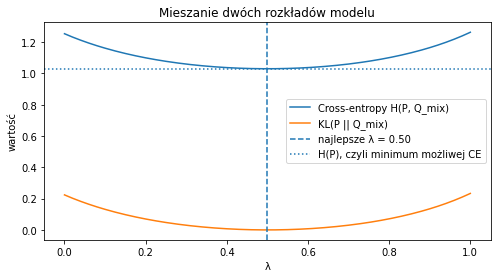

In [7]:
# Rozkład docelowy
P = np.array([0.5, 0.3, 0.2])

# Dwa rozkłady modelu
Q1 = np.array([0.8, 0.1, 0.1])
Q2 = np.array([0.2, 0.5, 0.3])

# Wartości lambda od 0 do 1
lambdas = np.linspace(0, 1, 201)

ce_values = []
kl_values = []

for lam in lambdas:
    Q_mix = lam * Q1 + (1 - lam) * Q2
    
    ce_values.append(cross_entropy(P, Q_mix))
    kl_values.append(kl_divergence(P, Q_mix))

ce_values = np.array(ce_values)
kl_values = np.array(kl_values)

best_idx = np.argmin(kl_values)
best_lambda = lambdas[best_idx]

print(f"Najlepsze lambda: {best_lambda:.3f}")
print(f"Minimum cross-entropy H(P,Q_mix): {ce_values[best_idx]:.4f}")
print(f"Minimum KL(P||Q_mix): {kl_values[best_idx]:.4f}")
print(f"Entropy H(P): {entropy(P):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(lambdas, ce_values, label="Cross-entropy H(P, Q_mix)")
plt.plot(lambdas, kl_values, label="KL(P || Q_mix)")
plt.axvline(best_lambda, linestyle="--", label=f"najlepsze λ = {best_lambda:.2f}")
plt.axhline(entropy(P), linestyle=":", label="H(P), czyli minimum możliwej CE")

plt.xlabel("λ")
plt.ylabel("wartość")
plt.title("Mieszanie dwóch rozkładów modelu")
plt.legend()
plt.show()

## Interpretacja przykładu 1

Widzimy, że cross-entropy i KL divergence mają minimum w tym samym miejscu.

To nie jest przypadek.

Dla stałego rozkładu $P$ mamy:

$$
H(P,Q) = H(P) + KL(P||Q)
$$

Ponieważ $H(P)$ jest stałe, minimalizowanie cross-entropy względem $Q$ daje taki sam najlepszy rozkład jak minimalizowanie KL divergence.

Różnica jest taka, że cross-entropy jest przesunięta w górę o wartość entropii $H(P)$.

Praktyczna interpretacja:

> Jeżeli target $P$ jest ten sam, cross-entropy i KL divergence prowadzą do tego samego optimum.

Dlatego w klasyfikacji często używamy cross-entropy jako funkcji straty. Gdy prawdziwe etykiety są ustalone, minimalizacja cross-entropy oznacza, że model uczy się przypisywać coraz większe prawdopodobieństwo poprawnym klasom.

Ten przykład można też rozumieć jako prostą intuicję ensemblingu:

- jeden model przesadza w jedną stronę,
- drugi model przesadza w drugą stronę,
- ich mieszanka może być lepiej dopasowana do targetu.

In [8]:
# Porównajmy wartości dla Q1, Q2 oraz najlepszej mieszanki

Q_best = best_lambda * Q1 + (1 - best_lambda) * Q2

comparison = pd.DataFrame([
    {
        "rozkład": "Q1",
        "Q": Q1,
        "cross_entropy": cross_entropy(P, Q1),
        "kl_divergence": kl_divergence(P, Q1)
    },
    {
        "rozkład": "Q2",
        "Q": Q2,
        "cross_entropy": cross_entropy(P, Q2),
        "kl_divergence": kl_divergence(P, Q2)
    },
    {
        "rozkład": "Q_mix najlepszy",
        "Q": Q_best,
        "cross_entropy": cross_entropy(P, Q_best),
        "kl_divergence": kl_divergence(P, Q_best)
    }
])

comparison

,rozkład,Q,cross_entropy,kl_divergence
0,Q1,"[0.8, 0.1, 0.1]",1.262864,0.233211
1,Q2,"[0.2, 0.5, 0.3]",1.253458,0.223805
2,Q_mix najlepszy,"[0.5, 0.3, 0.2]",1.029653,0.000000


## Przykład 2: kiedy sama cross-entropy może być myląca

Teraz porównamy dwa różne przypadki.

### Przypadek A

Target jest prawie pewny:

$$
P = [0.99, 0.01]
$$

Model jest niedoskonały:

$$
Q = [0.8, 0.2]
$$

### Przypadek B

Target jest bardzo niepewny:

$$
P = [0.5, 0.5]
$$

Model jest idealny:

$$
Q = [0.5, 0.5]
$$

To pokazuje ważną rzecz:

> Cross-entropy zależy nie tylko od błędu modelu, ale też od naturalnej niepewności targetu.

Dlatego porównywanie samej wartości cross-entropy między różnymi problemami albo różnymi rozkładami $P$ może być mylące.

In [9]:
cases = [
    {
        "przypadek": "łatwy target, model niedoskonały",
        "P": np.array([0.99, 0.01]),
        "Q": np.array([0.8, 0.2])
    },
    {
        "przypadek": "niepewny target, model idealny",
        "P": np.array([0.5, 0.5]),
        "Q": np.array([0.5, 0.5])
    }
]

rows = []

for case in cases:
    P_case = case["P"]
    Q_case = case["Q"]
    
    rows.append({
        "przypadek": case["przypadek"],
        "P": P_case,
        "Q": Q_case,
        "H(P)": entropy(P_case),
        "Cross-entropy H(P,Q)": cross_entropy(P_case, Q_case),
        "KL(P||Q)": kl_divergence(P_case, Q_case)
    })

df = pd.DataFrame(rows)
df

,przypadek,P,Q,H(P),"Cross-entropy H(P,Q)",KL(P||Q)
0,"łatwy target, model niedoskonały","[0.99, 0.01]","[0.8, 0.2]",0.056002,0.237006,0.181005
1,"niepewny target, model idealny","[0.5, 0.5]","[0.5, 0.5]",0.693147,0.693147,0.000000


## Interpretacja przykładu 2

W drugim przypadku model jest idealny, bo:

$$
P = Q = [0.5, 0.5]
$$

Dlatego:

$$
KL(P||Q) = 0
$$

Nie ma żadnego niedopasowania między targetem a modelem.

Mimo to cross-entropy nie jest równa zero. Wynosi około:

$$
0.693
$$

Dlaczego?

Bo sam target jest niepewny. Rozkład:

$$
P = [0.5, 0.5]
$$

ma wysoką entropię.

Z kolei w pierwszym przypadku target jest prawie deterministyczny:

$$
P = [0.99, 0.01]
$$

Model nie jest idealny, ale cross-entropy może być niższa niż w przypadku idealnego modelu dla niepewnego targetu.

Wniosek:

> Niższa cross-entropy nie zawsze oznacza, że model jest lepiej dopasowany, jeżeli porównujemy różne rozkłady docelowe $P$.

Cross-entropy miesza dwie rzeczy:

$$
H(P,Q) = H(P) + KL(P||Q)
$$

czyli:

- naturalną trudność targetu,
- niedopasowanie modelu.

KL divergence izoluje samo niedopasowanie modelu względem targetu.

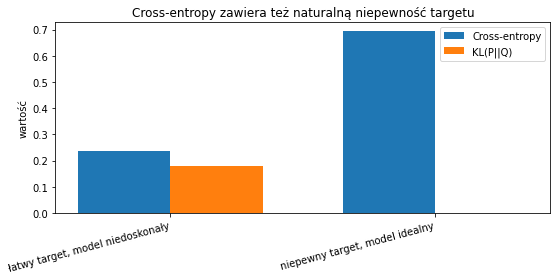

In [10]:
x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(8, 4))

plt.bar(
    x - width / 2,
    df["Cross-entropy H(P,Q)"],
    width,
    label="Cross-entropy"
)

plt.bar(
    x + width / 2,
    df["KL(P||Q)"],
    width,
    label="KL(P||Q)"
)

plt.xticks(x, df["przypadek"], rotation=15, ha="right")
plt.ylabel("wartość")
plt.title("Cross-entropy zawiera też naturalną niepewność targetu")
plt.legend()
plt.tight_layout()
plt.show()

## Przykład 3: KL divergence zależy od kierunku

KL divergence nie jest symetryczna.

To znaczy, że zwykle:

$$
KL(P||Q) \neq KL(Q||P)
$$

Porównajmy dwa rozkłady:

$$
P = [0.99, 0.01]
$$

$$
Q = [0.5, 0.5]
$$

Rozkład $P$ mówi:

> Prawie na pewno pierwsza klasa.

Rozkład $Q$ mówi:

> Nie wiem, obie klasy są równie możliwe.

Sprawdzimy teraz dwie wartości:

$$
KL(P||Q)
$$

oraz:

$$
KL(Q||P)
$$

KL(P||Q) = 0.6371
KL(Q||P) = 1.6145


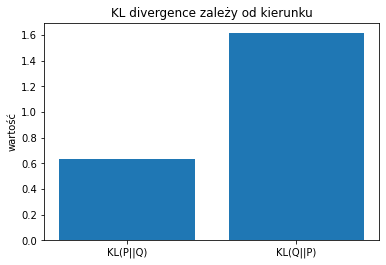

In [11]:
P = np.array([0.99, 0.01])
Q = np.array([0.5, 0.5])

kl_pq = kl_divergence(P, Q)
kl_qp = kl_divergence(Q, P)

print(f"KL(P||Q) = {kl_pq:.4f}")
print(f"KL(Q||P) = {kl_qp:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["KL(P||Q)", "KL(Q||P)"], [kl_pq, kl_qp])
plt.ylabel("wartość")
plt.title("KL divergence zależy od kierunku")
plt.show()

## Interpretacja przykładu 3

Wartości:

$$
KL(P||Q)
$$

oraz:

$$
KL(Q||P)
$$

są różne, ponieważ odpowiadają na różne pytania.

### $KL(P||Q)$

Pyta:

> Ile tracimy, jeśli prawdziwy rozkład jest prawie pewny, ale model jest niepewny?

Czyli prawda mówi:

$$
P = [0.99, 0.01]
$$

a model mówi:

$$
Q = [0.5, 0.5]
$$

Model nie jest bardzo pewny błędnej odpowiedzi. Jest raczej niezdecydowany.

### $KL(Q||P)$

Pyta:

> Ile tracimy, jeśli dane pochodzą z bardziej rozmytego rozkładu $Q$, ale opisujemy je bardzo pewnym rozkładem $P$?

Tutaj problem jest inny. Rozkład $P$ przypisuje bardzo małe prawdopodobieństwo drugiej klasie:

$$
0.01
$$

Jeżeli rozkład $Q$ uważa drugą klasę za całkiem możliwą:

$$
0.5
$$

to kara robi się większa.

Wniosek:

> KL divergence nie działa jak zwykła odległość. Kierunek ma znaczenie.

In [12]:

# Jeszcze jeden przykład asymetrii KL:
# porównujemy rozkład bardzo pewny z rozkładem mniej pewnym.

examples = [
    {
        "P": np.array([0.99, 0.01]),
        "Q": np.array([0.5, 0.5])
    },
    {
        "P": np.array([0.9, 0.1]),
        "Q": np.array([0.6, 0.4])
    },
    {
        "P": np.array([0.7, 0.3]),
        "Q": np.array([0.5, 0.5])
    }
]

rows = []

for i, example in enumerate(examples, start=1):
    P_ex = example["P"]
    Q_ex = example["Q"]
    
    rows.append({
        "przykład": i,
        "P": P_ex,
        "Q": Q_ex,
        "KL(P||Q)": kl_divergence(P_ex, Q_ex),
        "KL(Q||P)": kl_divergence(Q_ex, P_ex),
        "różnica": kl_divergence(P_ex, Q_ex) - kl_divergence(Q_ex, P_ex)
    })

kl_direction_df = pd.DataFrame(rows)
kl_direction_df

,przykład,P,Q,KL(P||Q),KL(Q||P),różnica
0,1,"[0.99, 0.01]","[0.5, 0.5]",0.637146,1.614463,-0.977317
1,2,"[0.9, 0.1]","[0.6, 0.4]",0.226289,0.311239,-0.084950
2,3,"[0.7, 0.3]","[0.5, 0.5]",0.082283,0.087177,-0.004894


## Co to daje w praktyce?

### Cross-entropy

Cross-entropy jest bardzo wygodna jako funkcja straty w klasyfikacji.

Jeżeli prawdziwa etykieta jest typu one-hot, na przykład:

$$
P = [1,0,0]
$$

to cross-entropy upraszcza się do:

$$
H(P,Q) = -\log Q_{\text{true class}}
$$

Czyli model dostaje karę zależną od tego, jakie prawdopodobieństwo przypisał poprawnej klasie.

Przykład:

- jeśli model przypisał poprawnej klasie prawdopodobieństwo $0.9$, kara jest mała,
- jeśli przypisał $0.01$, kara jest bardzo duża.

### KL divergence

KL divergence jest wygodna, gdy chcemy porównać dwa pełne rozkłady.

Przykłady:

- rozkład nauczyciela i ucznia w knowledge distillation,
- rozkład danych i rozkład modelu generatywnego,
- podobieństwa punktów w wysokim i niskim wymiarze,
- rozkład przed treningiem i po treningu.

W skrócie:

> Cross-entropy jest często używana jako loss do trenowania modelu.

> KL divergence jest często używana do mierzenia niedopasowania między dwoma rozkładami.

In [13]:
# Prosty przykład klasyfikacyjny:
# prawdziwa klasa to klasa 0, czyli P = [1, 0, 0].

P_true = np.array([1.0, 0.0, 0.0])

models = [
    {
        "model": "bardzo dobry",
        "Q": np.array([0.90, 0.08, 0.02])
    },
    {
        "model": "niepewny",
        "Q": np.array([0.40, 0.30, 0.30])
    },
    {
        "model": "bardzo zły",
        "Q": np.array([0.01, 0.89, 0.10])
    }
]

rows = []

for model in models:
    Q_model = model["Q"]
    
    rows.append({
        "model": model["model"],
        "Q": Q_model,
        "prawdopodobieństwo poprawnej klasy": Q_model[0],
        "cross_entropy": cross_entropy(P_true, Q_model),
        "-log(Q_true)": -np.log(Q_model[0] + EPS)
    })

classification_df = pd.DataFrame(rows)
classification_df

,model,Q,prawdopodobieństwo poprawnej klasy,cross_entropy,-log(Q_true)
0,bardzo dobry,"[0.9, 0.08, 0.02]",0.90,0.105361,0.105361
1,niepewny,"[0.4, 0.3, 0.3]",0.40,0.916291,0.916291
2,bardzo zły,"[0.01, 0.89, 0.1]",0.01,4.605170,4.605170


## Interpretacja przykładu klasyfikacyjnego

Dla etykiety one-hot:

$$
P = [1,0,0]
$$

cross-entropy wynosi:

$$
H(P,Q) = -\log Q_{\text{true class}}
$$

Dlatego liczy się tylko prawdopodobieństwo przypisane poprawnej klasie.

Jeżeli poprawna jest klasa 0:

- model $[0.90, 0.08, 0.02]$ ma mały loss,
- model $[0.40, 0.30, 0.30]$ ma większy loss,
- model $[0.01, 0.89, 0.10]$ ma bardzo duży loss.

To pokazuje, dlaczego cross-entropy mocno karze modele, które są bardzo pewne błędnej odpowiedzi.

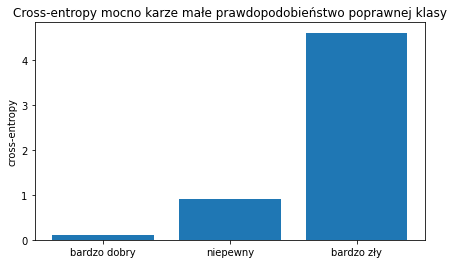

In [14]:
plt.figure(figsize=(7, 4))

plt.bar(
    classification_df["model"],
    classification_df["cross_entropy"]
)

plt.ylabel("cross-entropy")
plt.title("Cross-entropy mocno karze małe prawdopodobieństwo poprawnej klasy")
plt.show()

## Połączenie z t-SNE i UMAP

W metodach redukcji wymiarowości też porównujemy rozkłady albo grafy podobieństw.

W t-SNE intuicja jest taka:

- $P$ opisuje podobieństwa punktów w oryginalnej przestrzeni,
- $Q$ opisuje podobieństwa punktów w przestrzeni 2D.

t-SNE minimalizuje funkcję podobną do:

$$
KL(P||Q)
$$

czyli próbuje sprawić, żeby punkty podobne w wysokim wymiarze były również podobne w niskim wymiarze.

W UMAP mamy podobną ideę, ale loss jest bliższy cross-entropy na grafie rozmytym:

$$
-\sum_{ij}
\left[
p_{ij}\log q_{ij}
+
(1-p_{ij})\log(1-q_{ij})
\right]
$$

gdzie:

- $p_{ij}$ mówi, jak silne jest połączenie między punktami $i$ oraz $j$ w oryginalnej przestrzeni,
- $q_{ij}$ mówi, jak silne jest połączenie między punktami $i$ oraz $j$ w przestrzeni 2D.

Interpretacja:

- jeśli $p_{ij}$ jest duże, punkty powinny być blisko,
- jeśli $p_{ij}$ jest małe, punkty powinny być daleko.

Ważona macierz sąsiedztwa w UMAP-ie to właśnie macierz wartości $p_{ij}$.
Embedding 2D generuje wartości $q_{ij}$.
Funkcja straty mierzy, jak bardzo graf w 2D różni się od grafu w oryginalnej przestrzeni.

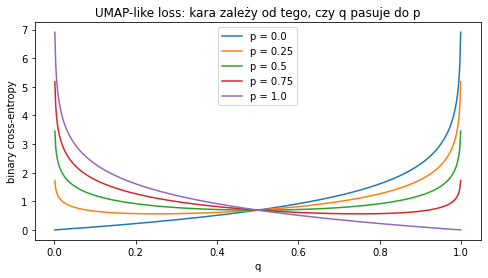

In [17]:
# Mini-przykład binary cross-entropy dla jednej pary punktów w UMAP-ie.
#
# p_ij mówi, jak bardzo punkty są połączone w oryginalnej przestrzeni.
# q_ij mówi, jak bardzo punkty są połączone w embeddingu 2D.

def binary_cross_entropy(p, q):
    q = np.clip(q, EPS, 1 - EPS)
    return -(p * np.log(q) + (1 - p) * np.log(1 - q))

q_values = np.linspace(0.001, 0.999, 500)

p_values = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(8, 4))

for p in p_values:
    losses = binary_cross_entropy(p, q_values)
    plt.plot(q_values, losses, label=f"p = {p}")

plt.xlabel("q")
plt.ylabel("binary cross-entropy")
plt.title("UMAP-like loss: kara zależy od tego, czy q pasuje do p")
plt.legend()
plt.show()

## Interpretacja przykładu UMAP-like

Na wykresie:

- $p$ to targetowe podobieństwo pary punktów,
- $q$ to podobieństwo tej pary w embeddingu.

Jeżeli:

$$
p = 1
$$

to loss jest najmniejszy, gdy:

$$
q \approx 1
$$

Czyli punkty powinny być blisko.

Jeżeli:

$$
p = 0
$$

to loss jest najmniejszy, gdy:

$$
q \approx 0
$$

Czyli punkty powinny być daleko.

Jeżeli:

$$
p = 0.5
$$

to loss jest najmniejszy w okolicy:

$$
q \approx 0.5
$$

Czyli model nie powinien być ani zbyt pewny, że punkty są połączone, ani zbyt pewny, że nie są połączone.

To dobrze pokazuje intuicję UMAP-a:

> UMAP buduje graf podobieństw w oryginalnej przestrzeni, a potem szuka takiego embeddingu 2D, którego graf podobieństw jak najlepiej odtwarza graf oryginalny.

In [18]:
# Podsumowanie zależności H(P,Q) = H(P) + KL(P||Q)
# na jednym konkretnym przykładzie.

P = np.array([0.5, 0.3, 0.2])
Q = np.array([0.4, 0.4, 0.2])

H_P = entropy(P)
CE_PQ = cross_entropy(P, Q)
KL_PQ = kl_divergence(P, Q)

summary_df = pd.DataFrame([
    {
        "wielkość": "H(P)",
        "wartość": H_P,
        "interpretacja": "naturalna niepewność targetu"
    },
    {
        "wielkość": "KL(P||Q)",
        "wartość": KL_PQ,
        "interpretacja": "kara za niedopasowanie Q do P"
    },
    {
        "wielkość": "H(P,Q)",
        "wartość": CE_PQ,
        "interpretacja": "całkowity koszt używania Q zamiast P"
    },
    {
        "wielkość": "H(P) + KL(P||Q)",
        "wartość": H_P + KL_PQ,
        "interpretacja": "powinno być równe H(P,Q)"
    }
])

summary_df

,wielkość,wartość,interpretacja
0,H(P),1.029653,naturalna niepewność targetu
1,KL(P||Q),0.025267,kara za niedopasowanie Q do P
2,"H(P,Q)",1.054920,całkowity koszt używania Q zamiast P
3,H(P) + KL(P||Q),1.054920,"powinno być równe H(P,Q)"


## Najważniejsza puenta

Cross-entropy odpowiada na pytanie:

> Ile kosztuje używanie predykcji modelu $Q$, gdy dane pochodzą z rozkładu $P$?

KL divergence odpowiada na pytanie:

> Ile dodatkowo tracimy przez to, że używamy $Q$ zamiast idealnego rozkładu $P$?

Ich związek to:

$$
H(P,Q) = H(P) + KL(P||Q)
$$

Dlatego:

- jeśli $P$ jest stałe, minimalizacja cross-entropy i KL divergence prowadzi do tego samego optimum względem $Q$;
- jeśli porównujemy różne rozkłady $P$, sama cross-entropy może być myląca;
- KL divergence lepiej izoluje niedopasowanie między rozkładami;
- cross-entropy jest bardzo wygodna jako funkcja straty w uczeniu klasyfikatorów;
- w UMAP-ie podobna intuicja pojawia się przy porównywaniu grafu podobieństw z oryginalnej przestrzeni z grafem podobieństw w embeddingu.